In [12]:
import os
import json
import bilby
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM, Planck18

# =========================================================
# Optional: define custom prior class in case result/prior uses it
# =========================================================
class UniformReflected(bilby.core.prior.analytical.Uniform):
    def rescale(self, val):
        u = 2 * np.minimum(val, 1 - val)
        return super().rescale(u)

# ==============================
# User inputs
# ==============================
POP_OUTDIR = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_exactfd"
OUTDIR = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_test"   # 改成你的 PE 输出目录
EVENT_INDEX = 1
LABEL = f"bns_event_{EVENT_INDEX:04d}_eosfit_dyn_Mc0.1_test0424"   # 改成你真正的 label
RW_LABEL = LABEL + "_reweighted"                          # 如果想看 reweighted，可改这里
USE_REWEIGHTED = True                                         # True 看 reweighted；False 看原始 RB posterior

EVENT_NAME = f"event_{EVENT_INDEX:04d}"

# ==============================
# Load meta / truth
# ==============================
meta_path = os.path.join(POP_OUTDIR, EVENT_NAME, "meta.json")
with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

inj = dict(meta["injection_parameters"])

# ==============================
# Choose result file
# ==============================
if USE_REWEIGHTED:
    result_file = os.path.join(OUTDIR, f"{RW_LABEL}_result.json")
    if not os.path.exists(result_file):
        # fallback: use original result.json if reweighted result json is not present
        result_file = os.path.join(OUTDIR, f"{LABEL}_result.json")
else:
    result_file = os.path.join(OUTDIR, f"{LABEL}_result.json")

# truth H0 used in your current scripts
H0_TRUE = float(Planck18.H0.value)

# prior overlay sample size; default = posterior size
N_PRIOR = None

# =========================================================
# Load result
# =========================================================
result = bilby.core.result.read_in_result(filename=result_file)

# =========================================================
# EOS-fit helpers: same mapping as your PE/reweight script
# =========================================================
LAMBDA_FIT_NORM = 3500.0
A0_FIT = -0.51480556
A1_FIT = 0.79244108
A2_FIT = -0.30781804

cosmo_fid = FlatLambdaCDM(H0=70.0, Om0=float(Planck18.Om0), Tcmb0=Planck18.Tcmb0)
_z_grid = np.linspace(0.0, 2.0, 20000)
_dL_grid = np.asarray(cosmo_fid.luminosity_distance(_z_grid).value, dtype=float)

def z_from_dL_H0_vec(dL_mpc, H0):
    dL_scaled = np.asarray(dL_mpc, dtype=float) * (np.asarray(H0, dtype=float) / 70.0)
    return np.interp(np.clip(dL_scaled, _dL_grid[0], _dL_grid[-1]), _dL_grid, _z_grid)

def lambda_of_mbar_vec(mbar, delta_a0, delta_a1, delta_a2):
    mbar = np.asarray(mbar, dtype=float)
    poly = (
        1.0
        + A0_FIT * (1.0 + np.asarray(delta_a0, dtype=float))
        + A1_FIT * (1.0 + np.asarray(delta_a1, dtype=float)) * mbar
        + A2_FIT * (1.0 + np.asarray(delta_a2, dtype=float)) * mbar**2
    )
    lam = LAMBDA_FIT_NORM * poly / mbar**5
    lam = np.where(np.isfinite(lam), lam, 0.0)
    return np.maximum(lam, 1e-8)

def ensure_dataframe(x):
    if isinstance(x, pd.DataFrame):
        return x.copy()
    if isinstance(x, dict):
        return pd.DataFrame(x)
    return pd.DataFrame(x)

def add_ur_derived_parameters(parameters, h0_true=H0_TRUE):
    p = dict(parameters)

    dL = np.asarray(p["luminosity_distance"], dtype=float)
    H0 = np.asarray(p.get("H0_sample", h0_true), dtype=float)
    delta_a0 = np.asarray(p.get("delta_a0", 0.0), dtype=float)
    delta_a1 = np.asarray(p.get("delta_a1", 0.0), dtype=float)
    delta_a2 = np.asarray(p.get("delta_a2", 0.0), dtype=float)

    if "mass_1" not in p:
        q = np.asarray(p["mass_ratio"], dtype=float)
        Mc = np.asarray(p["chirp_mass"], dtype=float)
        p["mass_1"] = Mc * (1.0 + q) ** (1.0 / 5.0) * q ** (-3.0 / 5.0)
        p["mass_2"] = np.asarray(p["mass_1"], dtype=float) * q

    z = z_from_dL_H0_vec(dL, H0)
    p["redshift_sample"] = z

    m1_src = np.asarray(p["mass_1"], dtype=float) / (1.0 + z)
    m2_src = np.asarray(p["mass_2"], dtype=float) / (1.0 + z)
    p["mass_1_source"] = m1_src
    p["mass_2_source"] = m2_src

    p["lambda_1"] = lambda_of_mbar_vec(m1_src, delta_a0, delta_a1, delta_a2)
    p["lambda_2"] = lambda_of_mbar_vec(m2_src, delta_a0, delta_a1, delta_a2)

    p["lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(
        p["lambda_1"], p["lambda_2"], p["mass_1"], p["mass_2"]
    )
    p["delta_lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(
        p["lambda_1"], p["lambda_2"], p["mass_1"], p["mass_2"]
    )
    return p

# =========================================================
# Parameters to compare
# =========================================================
plot_params = [
    "chirp_mass",
    "mass_ratio",
    "luminosity_distance",
    "redshift_sample",
    "H0_sample",
    "delta_a0",
    "delta_a1",
    "delta_a2",
]

label_map = {
    "chirp_mass": r"$\mathcal{M}_c$",
    "mass_ratio": r"$q$",
    "luminosity_distance": r"$d_L$",
    "redshift_sample": r"$z$",
    "H0_sample": r"$H_0$",
    "delta_a0": r"$\delta a_0$",
    "delta_a1": r"$\delta a_1$",
    "delta_a2": r"$\delta a_2$",
}
plot_labels = [label_map[p] for p in plot_params]

# =========================================================
# Build posterior dataframe and add derived quantities
# =========================================================
post_df = ensure_dataframe(result.posterior)
post_df = ensure_dataframe(add_ur_derived_parameters(post_df))
post_df = post_df.replace([np.inf, -np.inf], np.nan).dropna(subset=plot_params).reset_index(drop=True)

# =========================================================
# Build truth dictionary
# =========================================================
m1_det = float(meta["mass_1_detector"])
m2_det = float(meta["mass_2_detector"])

truth_dict = {
    "chirp_mass": (m1_det * m2_det) ** (3.0 / 5.0) / (m1_det + m2_det) ** (1.0 / 5.0),
    "mass_ratio": min(m1_det, m2_det) / max(m1_det, m2_det),
    "luminosity_distance": float(inj["luminosity_distance"]),
    "redshift_sample": float(meta.get("z", np.nan)),
    "H0_sample": float(H0_TRUE),
    "delta_a0": 0.0,
    "delta_a1": 0.0,
    "delta_a2": 0.0,
}
print("truth_dict =", truth_dict)

# =========================================================
# Sample from stored priors, then add derived quantities
# Note: z is not a sampled parameter; it is derived from dL and H0
# =========================================================
n_prior = len(post_df) if N_PRIOR is None else int(N_PRIOR)

if hasattr(result.priors, "non_fixed_keys"):
    sample_keys = [k for k in result.priors.non_fixed_keys if k in result.priors]
else:
    sample_keys = list(result.priors.keys())

prior_samples = result.priors.sample_subset_constrained(keys=sample_keys, size=n_prior)
prior_df = pd.DataFrame(prior_samples)
prior_df = ensure_dataframe(add_ur_derived_parameters(prior_df))
prior_df = prior_df.replace([np.inf, -np.inf], np.nan).dropna(subset=plot_params).reset_index(drop=True)

n_plot = min(len(post_df), len(prior_df))
post_df = post_df.iloc[:n_plot].reset_index(drop=True)
prior_df = prior_df.iloc[:n_plot].reset_index(drop=True)

print(f"posterior samples used = {len(post_df)}")
print(f"prior samples used     = {len(prior_df)}")

# =========================================================
# Build lightweight Result objects for bilby plot_multiple
# =========================================================
prior_result = bilby.core.result.Result(
    label=result.label + "_prior_overlay",
    outdir=result.outdir,
    sampler="prior",
    search_parameter_keys=plot_params,
    priors=result.priors,
    posterior=prior_df[plot_params].copy(),
    parameter_labels=plot_labels,
    parameter_labels_with_unit=plot_labels,
)
prior_result.injection_parameters = None

post_result = bilby.core.result.Result(
    label=result.label + "_posterior_overlay",
    outdir=result.outdir,
    sampler=result.sampler,
    search_parameter_keys=plot_params,
    priors=result.priors,
    posterior=post_df[plot_params].copy(),
    parameter_labels=plot_labels,
    parameter_labels_with_unit=plot_labels,
)
post_result.injection_parameters = None

# =========================================================
# Plot posterior vs prior
# =========================================================
# fig = bilby.core.result.plot_multiple(
#     [post_result, prior_result],
#     labels=["posterior", "prior"],
#     parameters=plot_params,
#     save=False,
#     bins=40,
# )
fig = bilby.core.result.plot_corner(post_result)
# =========================================================
# Overlay truth lines in red
# =========================================================
ndim = len(plot_params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, yparam in enumerate(plot_params):
    ytruth = truth_dict.get(yparam, None)

    if ytruth is not None and np.isfinite(ytruth):
        axes[i, i].axvline(ytruth, color="red", lw=1.5)

    for j in range(i):
        xparam = plot_params[j]
        xtruth = truth_dict.get(xparam, None)
        ax = axes[i, j]

        if xtruth is not None and np.isfinite(xtruth):
            ax.axvline(xtruth, color="red", lw=1.0)
        if ytruth is not None and np.isfinite(ytruth):
            ax.axhline(ytruth, color="red", lw=1.0)

plt.show()

truth_dict = {'chirp_mass': 1.2928188143651635, 'mass_ratio': 0.9568816737336133, 'luminosity_distance': 849.0022901291151, 'redshift_sample': 0.17065631422235847, 'H0_sample': 67.66, 'delta_a0': 0.0, 'delta_a1': 0.0, 'delta_a2': 0.0}
posterior samples used = 872
prior samples used     = 872


AttributeError: module 'bilby.core.result' has no attribute 'corner'

Using result file: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_test/bns_event_0001_eosfit_dyn_Mc0.1_test0424_result.json
truth_dict = {'chirp_mass': 1.2928188143651635, 'mass_ratio': 0.9568816737336133, 'luminosity_distance': 849.0022901291151, 'm_1': 1.518223238991255, 'm_2': 1.4527599940272198, 'lambda_tilde': np.float64(1059.280364353126), 'delta_lambda_tilde': np.float64(23.258822426515238)}
Sampling prior keys: ['luminosity_distance', 'theta_jn', 'psi', 'chi_1', 'chi_2', 'H0_sample', 'zenith', 'azimuth', 'chirp_mass', 'mass_ratio', 'geocent_time', 'delta_a0', 'delta_a1', 'delta_a2']
posterior samples used = 872
prior samples used     = 872


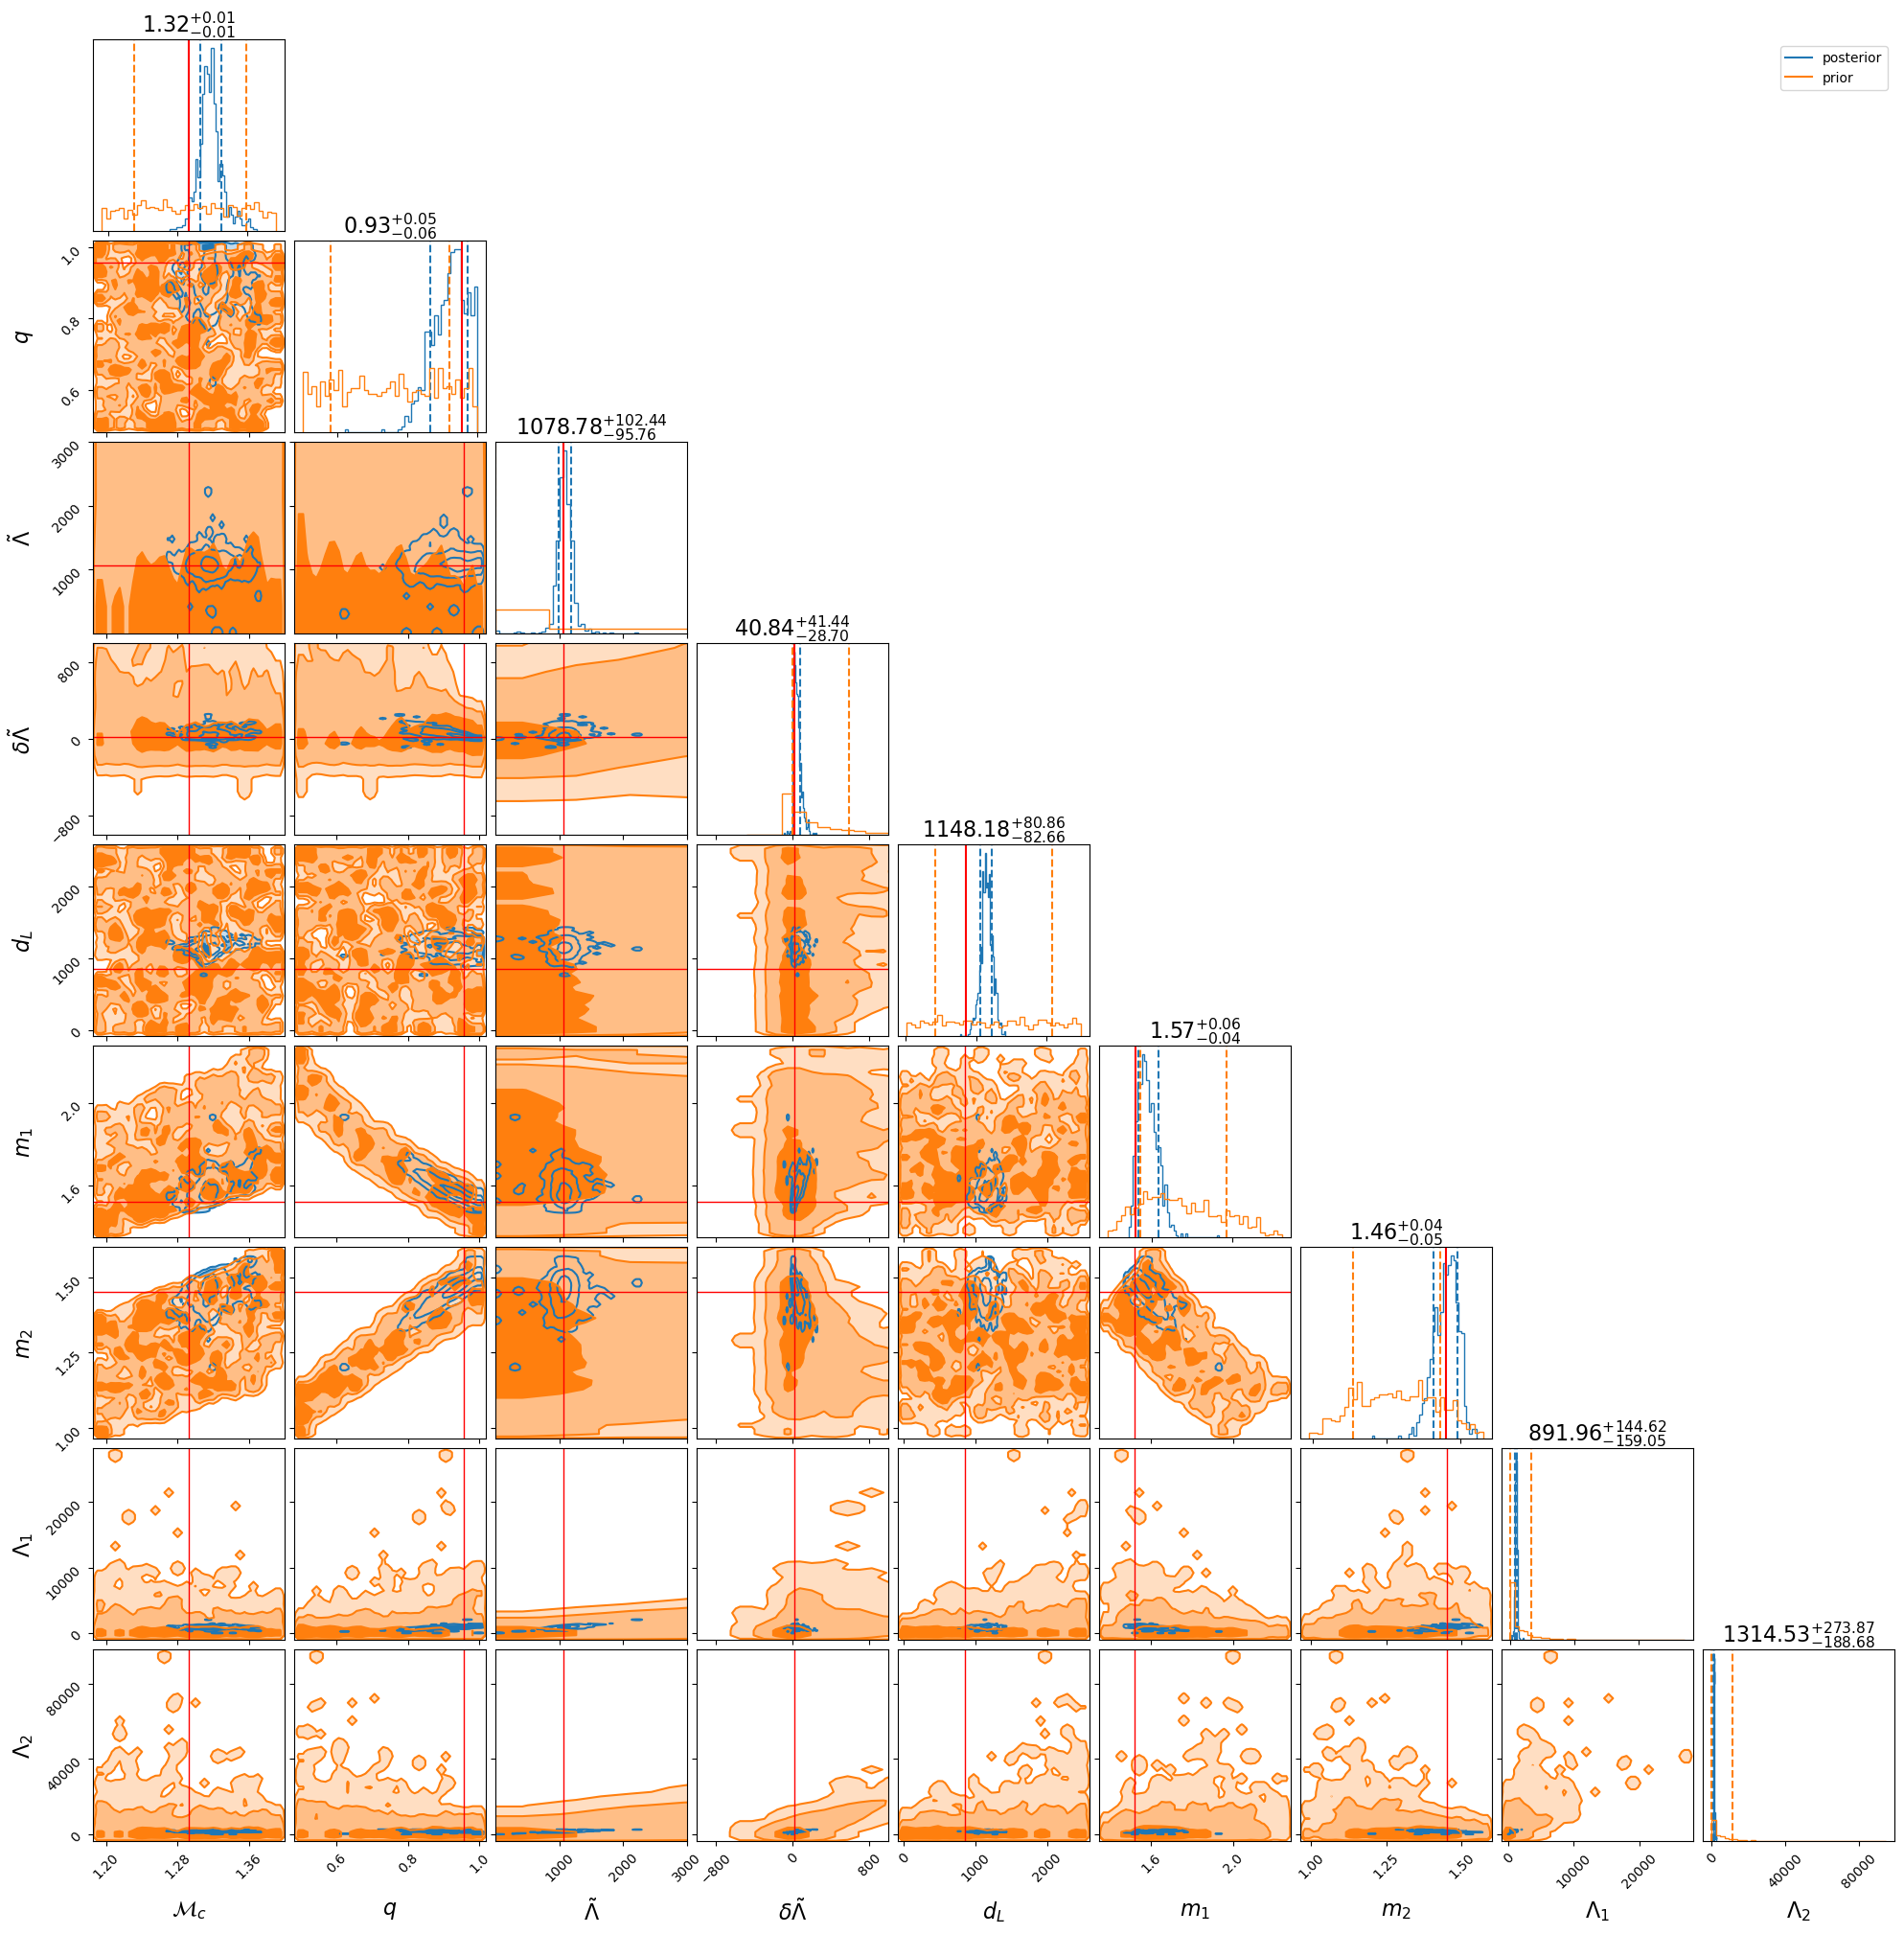

In [10]:
import os
import json
import bilby
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM, Planck18

# =========================================================
# Optional: define custom prior class in case result/prior uses it
# =========================================================
class UniformReflected(bilby.core.prior.analytical.Uniform):
    def rescale(self, val):
        u = 2 * np.minimum(val, 1 - val)
        return super().rescale(u)

# ==============================
# User inputs
# ==============================
POP_OUTDIR = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_exactfd"
OUTDIR = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_test"
EVENT_INDEX = 1
LABEL = f"bns_event_{EVENT_INDEX:04d}_eosfit_dyn_Mc0.1_test0424"
RW_LABEL = LABEL + "_reweighted"
USE_REWEIGHTED = True

EVENT_NAME = f"event_{EVENT_INDEX:04d}"

# truth H0 used in your current scripts
H0_TRUE = float(Planck18.H0.value)

# prior overlay sample size; default = posterior size
N_PRIOR = None

# =========================================================
# Load meta / truth
# =========================================================
meta_path = os.path.join(POP_OUTDIR, EVENT_NAME, "meta.json")
with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

inj = dict(meta["injection_parameters"])

# ==============================
# Choose result file
# ==============================
if USE_REWEIGHTED:
    result_file = os.path.join(OUTDIR, f"{RW_LABEL}_result.json")
    if not os.path.exists(result_file):
        result_file = os.path.join(OUTDIR, f"{LABEL}_result.json")
else:
    result_file = os.path.join(OUTDIR, f"{LABEL}_result.json")

print("Using result file:", result_file)

# =========================================================
# Load result
# =========================================================
result = bilby.core.result.read_in_result(filename=result_file)

# =========================================================
# EOS-fit helpers: same mapping as your PE/reweight script
# =========================================================
LAMBDA_FIT_NORM = 3500.0
A0_FIT = -0.51480556
A1_FIT = 0.79244108
A2_FIT = -0.30781804

cosmo_fid = FlatLambdaCDM(H0=70.0, Om0=float(Planck18.Om0), Tcmb0=Planck18.Tcmb0)
_z_grid = np.linspace(0.0, 2.0, 20000)
_dL_grid = np.asarray(cosmo_fid.luminosity_distance(_z_grid).value, dtype=float)

def z_from_dL_H0_vec(dL_mpc, H0):
    dL_scaled = np.asarray(dL_mpc, dtype=float) * (np.asarray(H0, dtype=float) / 70.0)
    return np.interp(np.clip(dL_scaled, _dL_grid[0], _dL_grid[-1]), _dL_grid, _z_grid)

def lambda_of_mbar_vec(mbar, delta_a0, delta_a1, delta_a2):
    mbar = np.asarray(mbar, dtype=float)
    poly = (
        1.0
        + A0_FIT * (1.0 + np.asarray(delta_a0, dtype=float))
        + A1_FIT * (1.0 + np.asarray(delta_a1, dtype=float)) * mbar
        + A2_FIT * (1.0 + np.asarray(delta_a2, dtype=float)) * mbar**2
    )
    lam = LAMBDA_FIT_NORM * poly / mbar**5
    lam = np.where(np.isfinite(lam), lam, 0.0)
    return np.maximum(lam, 1e-8)

def ensure_dataframe(x):
    if isinstance(x, pd.DataFrame):
        return x.copy()
    if isinstance(x, dict):
        return pd.DataFrame(x)
    return pd.DataFrame(x)

def add_ur_derived_parameters(parameters, h0_true=H0_TRUE):
    """
    Convert UR parameterization samples -> classic quantities.
    Always recompute component masses to avoid stale-key contamination.
    """
    p = ensure_dataframe(parameters).copy()

    dL = p["luminosity_distance"].to_numpy(dtype=float)
    H0 = p["H0_sample"].to_numpy(dtype=float) if "H0_sample" in p.columns else np.full(len(p), h0_true, dtype=float)
    delta_a0 = p["delta_a0"].to_numpy(dtype=float) if "delta_a0" in p.columns else np.zeros(len(p), dtype=float)
    delta_a1 = p["delta_a1"].to_numpy(dtype=float) if "delta_a1" in p.columns else np.zeros(len(p), dtype=float)
    delta_a2 = p["delta_a2"].to_numpy(dtype=float) if "delta_a2" in p.columns else np.zeros(len(p), dtype=float)

    q = p["mass_ratio"].to_numpy(dtype=float)
    Mc = p["chirp_mass"].to_numpy(dtype=float)

    # Always recompute detector-frame masses
    m1 = Mc * (1.0 + q) ** (1.0 / 5.0) * q ** (-3.0 / 5.0)
    m2 = m1 * q

    p["mass_1"] = m1
    p["mass_2"] = m2
    p["m_1"] = m1
    p["m_2"] = m2

    z = z_from_dL_H0_vec(dL, H0)
    p["redshift_sample"] = z

    m1_src = m1 / (1.0 + z)
    m2_src = m2 / (1.0 + z)
    p["mass_1_source"] = m1_src
    p["mass_2_source"] = m2_src

    lam1 = lambda_of_mbar_vec(m1_src, delta_a0, delta_a1, delta_a2)
    lam2 = lambda_of_mbar_vec(m2_src, delta_a0, delta_a1, delta_a2)

    p["lambda_1"] = lam1
    p["lambda_2"] = lam2

    p["lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(
        lam1, lam2, m1, m2
    )
    p["delta_lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(
        lam1, lam2, m1, m2
    )
    return p

# =========================================================
# Parameters to compare in classic parameterization
# =========================================================
plot_params = [
    "chirp_mass",
    "mass_ratio",
    "lambda_tilde",
    "delta_lambda_tilde",
    "luminosity_distance",
    "m_1",
    "m_2",
    "lambda_1",
    "lambda_2",
]

label_map = {
    "chirp_mass": r"$\mathcal{M}_c$",
    "mass_ratio": r"$q$",
    "lambda_tilde": r"$\tilde{\Lambda}$",
    "delta_lambda_tilde": r"$\delta\tilde{\Lambda}$",
    "luminosity_distance": r"$d_L$",
    "m_1": r"$m_1$",
    "m_2": r"$m_2$",
    "lambda_1": r"$\Lambda_1$",
    "lambda_2": r"$\Lambda_2$",
}
plot_labels = [label_map[p] for p in plot_params]

# =========================================================
# Build posterior dataframe and add classic derived quantities
# =========================================================
post_df = ensure_dataframe(result.posterior)
post_df = add_ur_derived_parameters(post_df)
post_df = post_df.replace([np.inf, -np.inf], np.nan).dropna(subset=plot_params).reset_index(drop=True)

# =========================================================
# Build truth dictionary in classic parameterization
# =========================================================
m1_det = float(meta["mass_1_detector"])
m2_det = float(meta["mass_2_detector"])

truth_dict = {
    "chirp_mass": (m1_det * m2_det) ** (3.0 / 5.0) / (m1_det + m2_det) ** (1.0 / 5.0),
    "mass_ratio": min(m1_det, m2_det) / max(m1_det, m2_det),
    "luminosity_distance": float(inj["luminosity_distance"]),
    "m_1": m1_det,
    "m_2": m2_det,
    "lambda_tilde": bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(
        float(inj["lambda_1"]), float(inj["lambda_2"]), m1_det, m2_det
    ),
    "delta_lambda_tilde": bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(
        float(inj["lambda_1"]), float(inj["lambda_2"]), m1_det, m2_det
    ),
}
print("truth_dict =", truth_dict)

# =========================================================
# Sample from stored priors, then map to classic quantities
# =========================================================
n_prior = len(post_df) if N_PRIOR is None else int(N_PRIOR)

if hasattr(result.priors, "non_fixed_keys"):
    sample_keys = [k for k in result.priors.non_fixed_keys if k in result.priors]
else:
    sample_keys = list(result.priors.keys())

print("Sampling prior keys:", sample_keys)

prior_samples = result.priors.sample_subset_constrained(keys=sample_keys, size=n_prior)
prior_df = pd.DataFrame(prior_samples)
prior_df = add_ur_derived_parameters(prior_df)
prior_df = prior_df.replace([np.inf, -np.inf], np.nan).dropna(subset=plot_params).reset_index(drop=True)

n_plot = min(len(post_df), len(prior_df))
post_df = post_df.iloc[:n_plot].reset_index(drop=True)
prior_df = prior_df.iloc[:n_plot].reset_index(drop=True)

print(f"posterior samples used = {len(post_df)}")
print(f"prior samples used     = {len(prior_df)}")

# =========================================================
# Build lightweight Result objects for bilby plot_multiple
# =========================================================
prior_result = bilby.core.result.Result(
    label=result.label + "_classic_prior_overlay",
    outdir=result.outdir,
    sampler="prior",
    search_parameter_keys=plot_params,
    priors=result.priors,
    posterior=prior_df[plot_params].copy(),
    parameter_labels=plot_labels,
    parameter_labels_with_unit=plot_labels,
)
prior_result.injection_parameters = None

post_result = bilby.core.result.Result(
    label=result.label + "_classic_posterior_overlay",
    outdir=result.outdir,
    sampler=result.sampler,
    search_parameter_keys=plot_params,
    priors=result.priors,
    posterior=post_df[plot_params].copy(),
    parameter_labels=plot_labels,
    parameter_labels_with_unit=plot_labels,
)
post_result.injection_parameters = None

# =========================================================
# Plot posterior vs prior
# =========================================================
fig = bilby.core.result.plot_multiple(
    [post_result, prior_result],
    labels=["posterior", "prior"],
    parameters=plot_params,
    save=False,
    bins=40,
)

# =========================================================
# Overlay truth lines in red
# =========================================================
ndim = len(plot_params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, yparam in enumerate(plot_params):
    ytruth = truth_dict.get(yparam, None)

    if ytruth is not None and np.isfinite(ytruth):
        axes[i, i].axvline(ytruth, color="red", lw=1.5)

    for j in range(i):
        xparam = plot_params[j]
        xtruth = truth_dict.get(xparam, None)
        ax = axes[i, j]

        if xtruth is not None and np.isfinite(xtruth):
            ax.axvline(xtruth, color="red", lw=1.0)
        if ytruth is not None and np.isfinite(ytruth):
            ax.axhline(ytruth, color="red", lw=1.0)

# =========================================================
# Optional: manually control x/y limits for selected parameters
# =========================================================
param_limits = {
    "lambda_tilde": (0, 3000),          # 改成你想要的 x/y 范围
    "delta_lambda_tilde": (-1000, 1000),  # 改成你想要的 x/y 范围
    "lambda_1": (0,1000),
    "lambda"
}

for i, yparam in enumerate(plot_params):
    for j, xparam in enumerate(plot_params):
        ax = axes[i, j]

        # upper triangle usually empty in bilby corner-style plots
        if j > i:
            continue

        # x-axis limit: depends on column parameter
        if xparam in param_limits:
            ax.set_xlim(param_limits[xparam])

        # y-axis limit: only for off-diagonal panels
        # diagonal panels' y-axis is density, usually不要手动设成参数范围
        if i != j and yparam in param_limits:
            ax.set_ylim(param_limits[yparam])
            
plt.show()

Using result file: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace_0421/outdir_population_run_traditional/bns_v6_event_0001_PSD_tidal_mc0001_reflected_result.json
Sampling prior keys: ['luminosity_distance', 'theta_jn', 'psi', 'chi_1', 'chi_2', 'zenith', 'azimuth', 'chirp_mass', 'mass_ratio', 'geocent_time', 'lambda_tilde', 'delta_lambda_tilde']
plot_params = ['chirp_mass', 'mass_ratio', 'lambda_tilde', 'delta_lambda_tilde', 'luminosity_distance', 'm_1', 'm_2']
posterior samples used = 1018
prior samples used     = 1018
truth_dict = {'chirp_mass': 1.2928188143651635, 'mass_ratio': 0.9568816737336133, 'luminosity_distance': 849.0022901291151, 'm_1': 1.518223238991255, 'm_2': 1.4527599940272198, 'lambda_tilde': np.float64(381.9504194447017), 'delta_lambda_tilde': np.float64(12.483821965309538)}


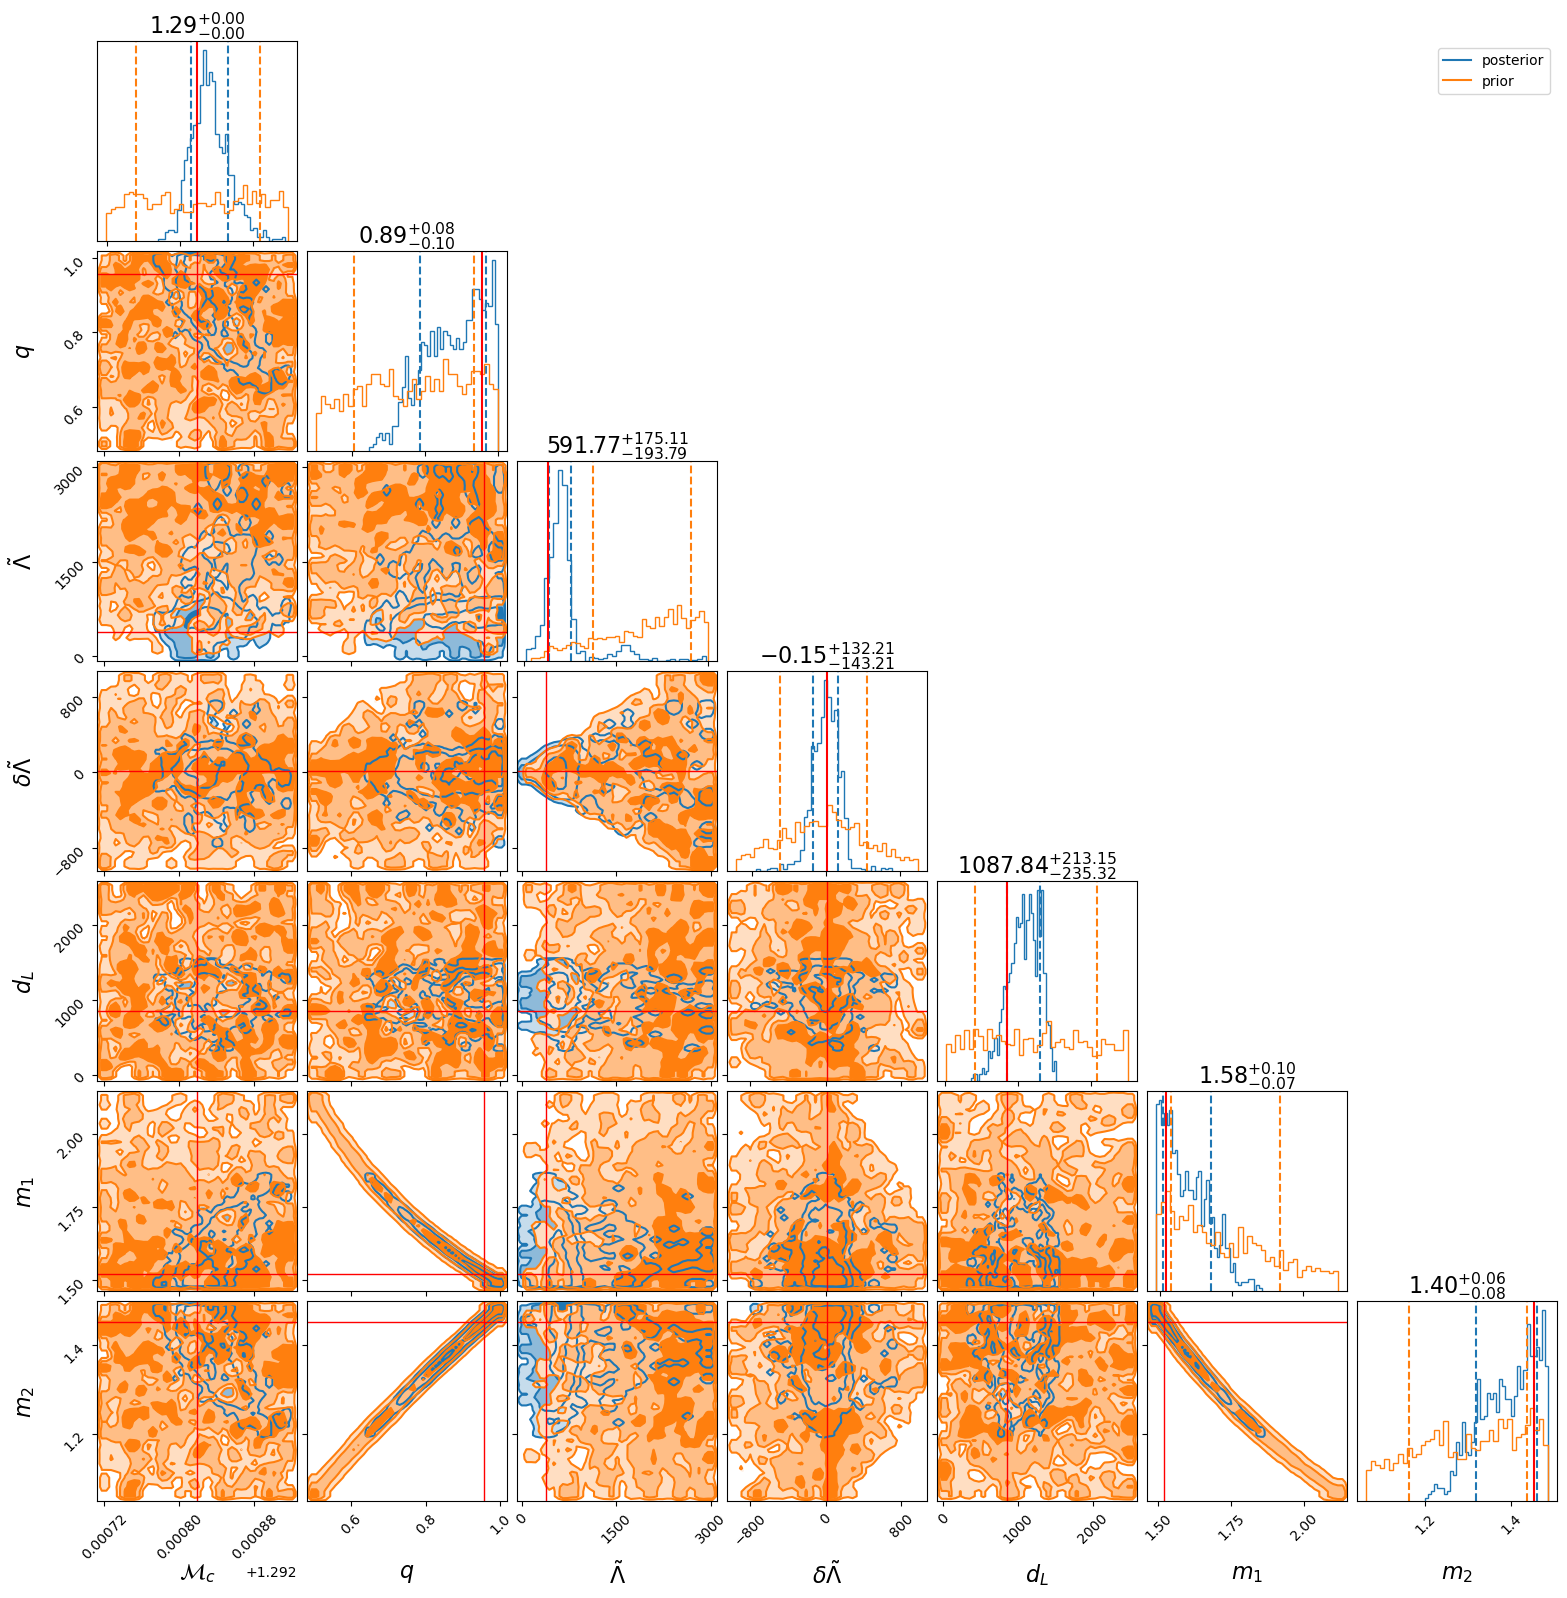

In [4]:
import os
import json
import bilby
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Optional: define custom prior class in case result/prior uses it
# =========================================================
class UniformReflected(bilby.core.prior.analytical.Uniform):
    def rescale(self, val):
        u = 2 * np.minimum(val, 1 - val)
        return super().rescale(u)

# ==============================
# User inputs
# ==============================
POP_OUTDIR = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace_0421/outdir_population_meta"
OUTDIR = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace_0421/outdir_population_run_traditional"

EVENT_INDEX = 1
LABEL = f"bns_v6_event_{EVENT_INDEX:04d}_PSD_tidal_mc0001_reflected"

EVENT_NAME = f"event_{EVENT_INDEX:04d}"

# prior overlay sample size; default = posterior size
N_PRIOR = None

# ==============================
# Load meta / truth
# ==============================
meta_path = os.path.join(POP_OUTDIR, EVENT_NAME, "meta.json")
with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

inj = dict(meta["injection_parameters"])
m1_det = float(meta["mass_1_detector"])
m2_det = float(meta["mass_2_detector"])

# ==============================
# Result file
# ==============================
result_file = os.path.join(OUTDIR, f"{LABEL}_result.json")
print("Using result file:", result_file)

# =========================================================
# Load result
# =========================================================
result = bilby.core.result.read_in_result(filename=result_file)

# =========================================================
# Helpers
# =========================================================
def ensure_dataframe(x):
    if isinstance(x, pd.DataFrame):
        return x.copy()
    if isinstance(x, dict):
        return pd.DataFrame(x)
    return pd.DataFrame(x)

def add_classic_columns(df):
    """
    Add/overwrite detector-frame component masses from chirp_mass and mass_ratio.
    Also add aliases m_1, m_2 for plotting.
    """
    df = ensure_dataframe(df).copy()

    if {"chirp_mass", "mass_ratio"}.issubset(df.columns):
        mc = df["chirp_mass"].to_numpy(dtype=float)
        q = df["mass_ratio"].to_numpy(dtype=float)

        m1 = mc * (1.0 + q) ** (1.0 / 5.0) * q ** (-3.0 / 5.0)
        m2 = m1 * q

        df["mass_1"] = m1
        df["mass_2"] = m2
        df["m_1"] = m1
        df["m_2"] = m2

    return df

def fill_fixed_prior_columns(df, priors, size):
    """
    If a parameter is fixed (e.g. DeltaFunction), sample_subset_constrained may not include it.
    Fill it back from the stored prior object.
    """
    df = ensure_dataframe(df).copy()

    for key in ["lambda_tilde", "delta_lambda_tilde", "chirp_mass", "mass_ratio", "luminosity_distance"]:
        if key in df.columns or key not in priors:
            continue

        prior_obj = priors[key]

        if hasattr(prior_obj, "peak"):
            df[key] = np.full(size, float(prior_obj.peak))
        elif hasattr(prior_obj, "minimum") and hasattr(prior_obj, "maximum"):
            # Should usually already be sampled if non-fixed, but keep this as fallback
            try:
                df[key] = np.asarray(prior_obj.sample(size=size), dtype=float)
            except TypeError:
                df[key] = np.asarray([prior_obj.sample() for _ in range(size)], dtype=float)

    return df

# =========================================================
# Parameters to compare
# =========================================================
requested_params = [
    "chirp_mass",
    "mass_ratio",
    "lambda_tilde",
    "delta_lambda_tilde",
    "luminosity_distance",
    "m_1",
    "m_2",
]

label_map = {
    "chirp_mass": r"$\mathcal{M}_c$",
    "mass_ratio": r"$q$",
    "lambda_tilde": r"$\tilde{\Lambda}$",
    "delta_lambda_tilde": r"$\delta\tilde{\Lambda}$",
    "luminosity_distance": r"$d_L$",
    "m_1": r"$m_1$",
    "m_2": r"$m_2$",
}

# =========================================================
# Posterior dataframe
# =========================================================
post_df = ensure_dataframe(result.posterior)

# If fixed tidal params were not stored in posterior, add them back as constants
n_post = len(post_df)
post_df = fill_fixed_prior_columns(post_df, result.priors, n_post)

# Add m1,m2 from chirp_mass and mass_ratio
post_df = add_classic_columns(post_df)

# =========================================================
# Prior samples
# =========================================================
n_prior = len(post_df) if N_PRIOR is None else int(N_PRIOR)

if hasattr(result.priors, "non_fixed_keys"):
    sample_keys = [k for k in result.priors.non_fixed_keys if k in result.priors]
else:
    sample_keys = list(result.priors.keys())

print("Sampling prior keys:", sample_keys)

prior_samples = result.priors.sample_subset_constrained(keys=sample_keys, size=n_prior)
prior_df = pd.DataFrame(prior_samples)

# If fixed tidal params were not sampled, add them back
prior_df = fill_fixed_prior_columns(prior_df, result.priors, n_prior)

# Add m1,m2 from chirp_mass and mass_ratio
prior_df = add_classic_columns(prior_df)

# =========================================================
# Keep only parameters available in both
# =========================================================
plot_params = [p for p in requested_params if p in post_df.columns and p in prior_df.columns]
plot_labels = [label_map[p] for p in plot_params]

post_df = post_df.replace([np.inf, -np.inf], np.nan).dropna(subset=plot_params).reset_index(drop=True)
prior_df = prior_df.replace([np.inf, -np.inf], np.nan).dropna(subset=plot_params).reset_index(drop=True)

n_plot = min(len(post_df), len(prior_df))
post_df = post_df.iloc[:n_plot].reset_index(drop=True)
prior_df = prior_df.iloc[:n_plot].reset_index(drop=True)

print("plot_params =", plot_params)
print(f"posterior samples used = {len(post_df)}")
print(f"prior samples used     = {len(prior_df)}")

# =========================================================
# Truth dictionary
# =========================================================
truth_dict = {
    "chirp_mass": (m1_det * m2_det) ** (3.0 / 5.0) / (m1_det + m2_det) ** (1.0 / 5.0),
    "mass_ratio": min(m1_det, m2_det) / max(m1_det, m2_det),
    "luminosity_distance": float(inj["luminosity_distance"]),
    "m_1": m1_det,
    "m_2": m2_det,
    "lambda_tilde": bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(
        float(inj["lambda_1"]), float(inj["lambda_2"]), m1_det, m2_det
    ),
    "delta_lambda_tilde": bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(
        float(inj["lambda_1"]), float(inj["lambda_2"]), m1_det, m2_det
    ),
}
print("truth_dict =", truth_dict)

# =========================================================
# Lightweight Result objects for bilby plot_multiple
# =========================================================
prior_result = bilby.core.result.Result(
    label=result.label + "_prior_overlay",
    outdir=result.outdir,
    sampler="prior",
    search_parameter_keys=plot_params,
    priors=result.priors,
    posterior=prior_df[plot_params].copy(),
    parameter_labels=plot_labels,
    parameter_labels_with_unit=plot_labels,
)
prior_result.injection_parameters = None

post_result = bilby.core.result.Result(
    label=result.label + "_posterior_overlay",
    outdir=result.outdir,
    sampler=result.sampler,
    search_parameter_keys=plot_params,
    priors=result.priors,
    posterior=post_df[plot_params].copy(),
    parameter_labels=plot_labels,
    parameter_labels_with_unit=plot_labels,
)
post_result.injection_parameters = None

# =========================================================
# Plot posterior vs prior
# =========================================================
fig = bilby.core.result.plot_multiple(
    [post_result, prior_result],
    labels=["posterior", "prior"],
    parameters=plot_params,
    save=False,
    bins=40,
)

# =========================================================
# Overlay truth lines in red
# =========================================================
ndim = len(plot_params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, yparam in enumerate(plot_params):
    ytruth = truth_dict.get(yparam, None)

    if ytruth is not None and np.isfinite(ytruth):
        axes[i, i].axvline(ytruth, color="red", lw=1.5)

    for j in range(i):
        xparam = plot_params[j]
        xtruth = truth_dict.get(xparam, None)
        ax = axes[i, j]

        if xtruth is not None and np.isfinite(xtruth):
            ax.axvline(xtruth, color="red", lw=1.0)
        if ytruth is not None and np.isfinite(ytruth):
            ax.axhline(ytruth, color="red", lw=1.0)

plt.show()

truth_dict = {'chirp_mass': 1.2928188143651635, 'mass_ratio': 0.9568816737336133, 'luminosity_distance': 849.0022901291151, 'redshift_sample': 0.17065631422235847, 'H0_sample': 67.66, 'delta_a0': 0.0, 'delta_a1': 0.0, 'delta_a2': 0.0}
posterior samples used   = 872
reweighted samples used  = 848


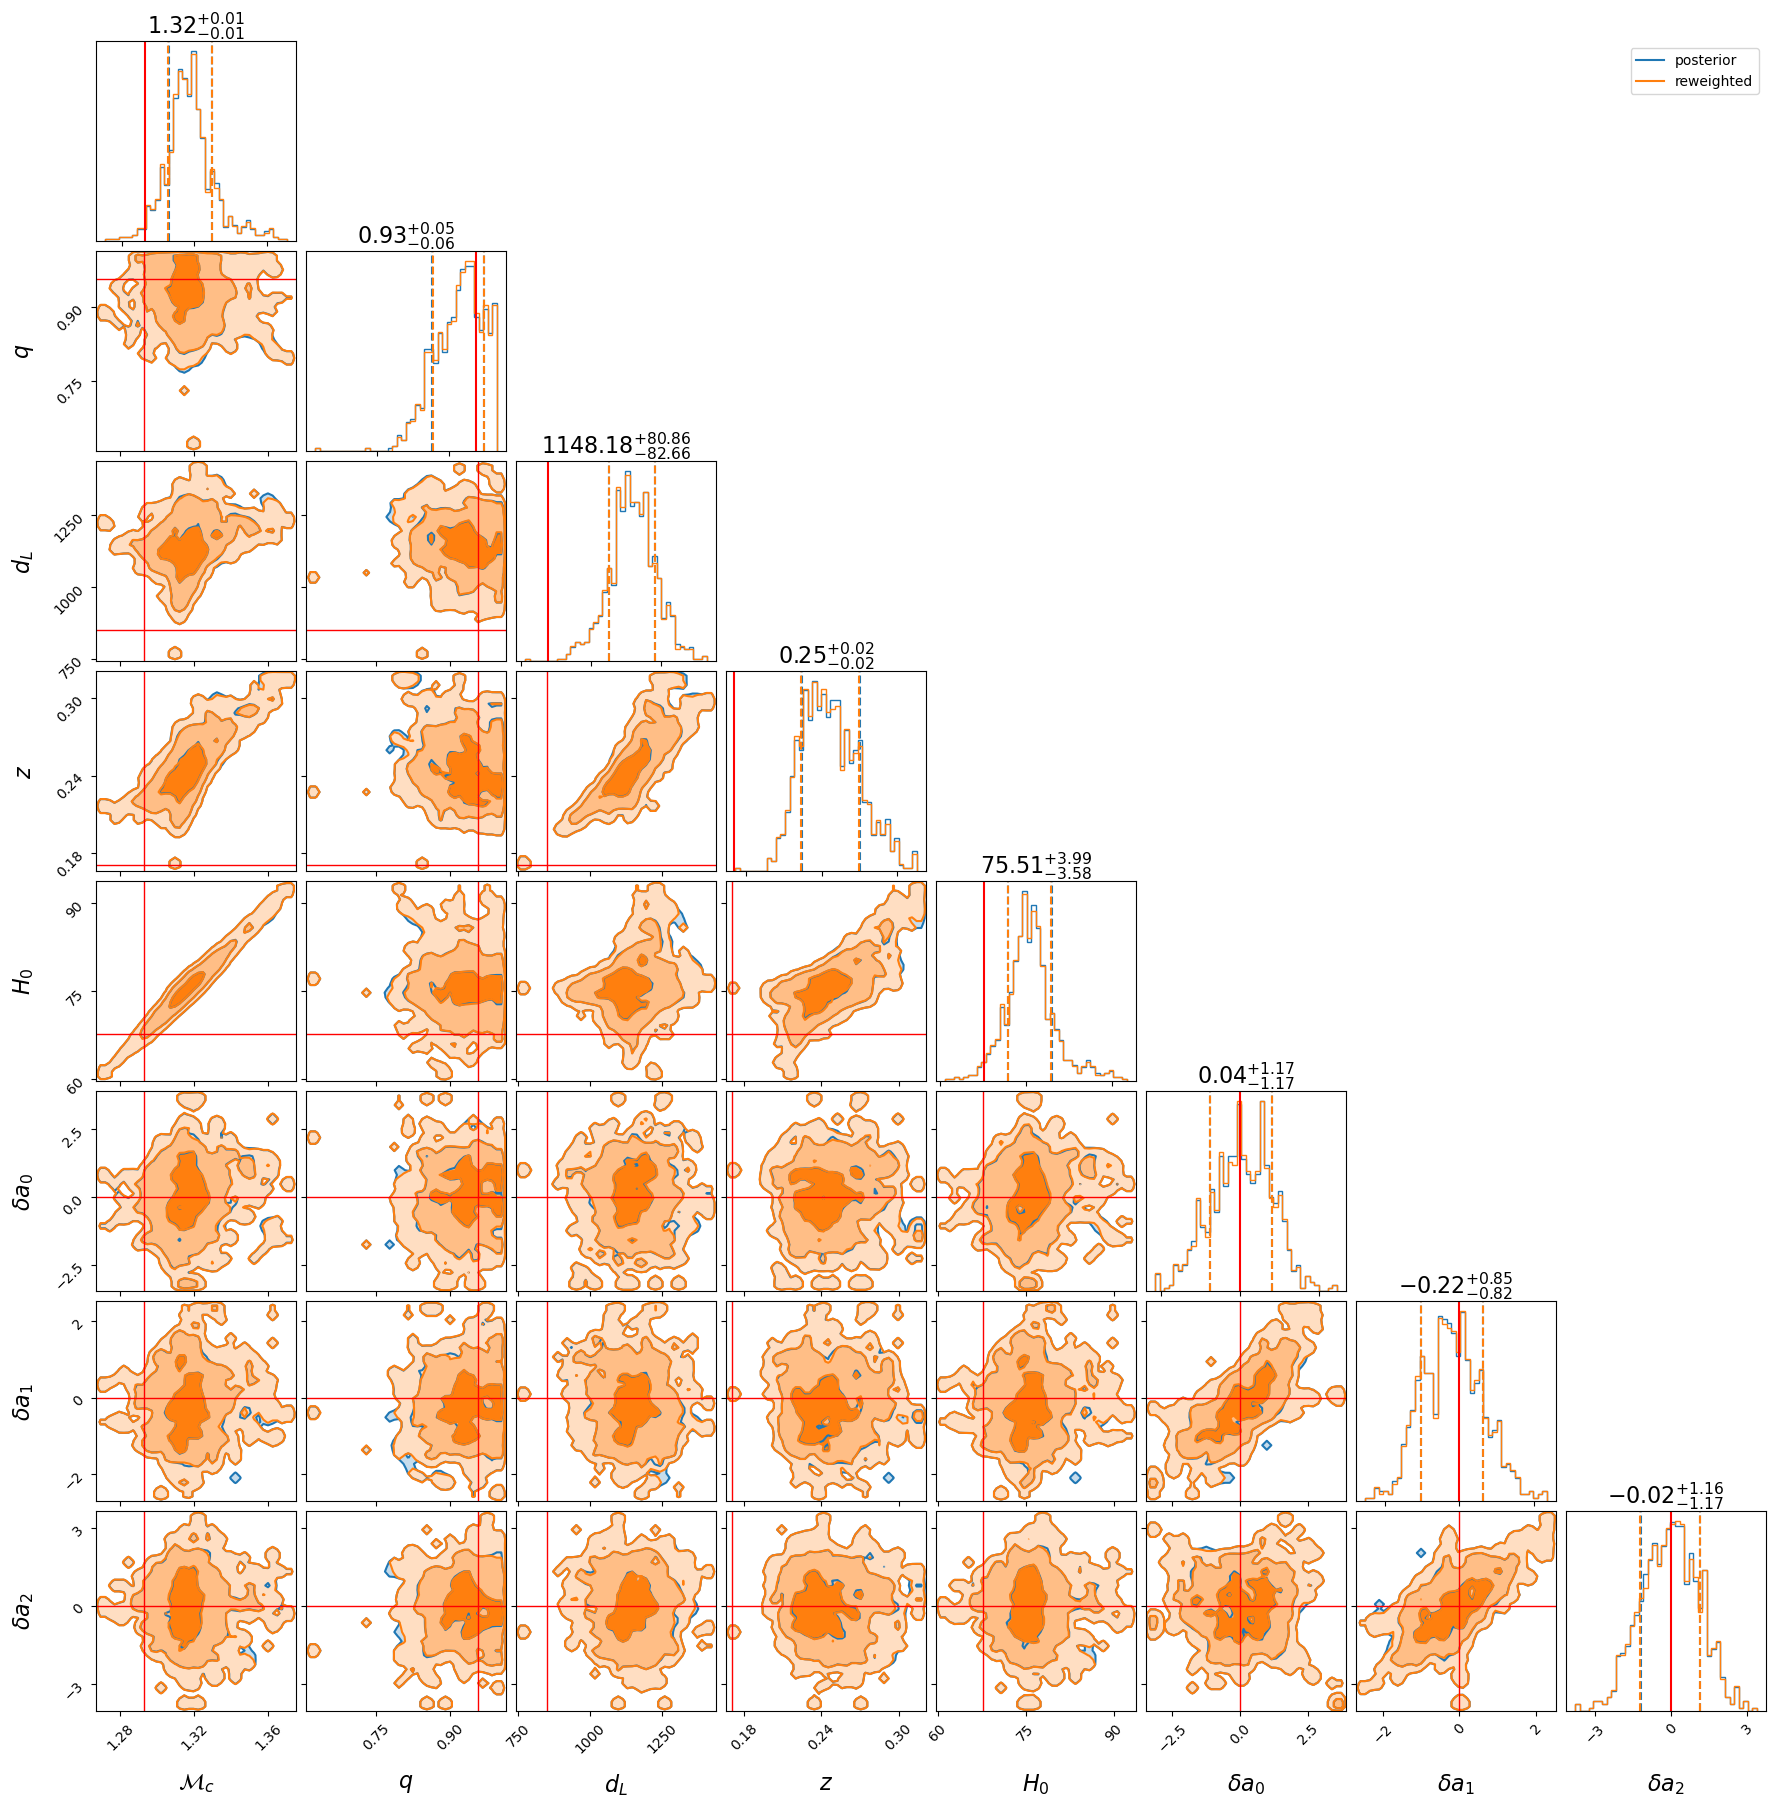

In [3]:
import os
import json
import bilby
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM, Planck18

# =========================================================
# Optional: define custom prior class in case result/prior uses it
# =========================================================
class UniformReflected(bilby.core.prior.analytical.Uniform):
    def rescale(self, val):
        u = 2 * np.minimum(val, 1 - val)
        return super().rescale(u)

# ==============================
# User inputs
# ==============================
POP_OUTDIR = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_exactfd"
OUTDIR = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_test"
EVENT_INDEX = 1

LABEL = f"bns_event_{EVENT_INDEX:04d}_eosfit_dyn_Mc0.1_test0424"
RW_LABEL = LABEL + "_reweighted"

EVENT_NAME = f"event_{EVENT_INDEX:04d}"

# ==============================
# Load meta / truth
# ==============================
meta_path = os.path.join(POP_OUTDIR, EVENT_NAME, "meta.json")
with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

inj = dict(meta["injection_parameters"])

# ==============================
# Files
# ==============================
result_file = os.path.join(OUTDIR, f"{LABEL}_result.json")
rw_csv_file = os.path.join(OUTDIR, f"{RW_LABEL}_posterior_augmented.csv")
rw_result_file = os.path.join(OUTDIR, f"{RW_LABEL}_result.json")

result = bilby.core.result.read_in_result(filename=result_file)

post_df = pd.DataFrame(result.posterior) if isinstance(result.posterior, dict) else result.posterior.copy()

if os.path.exists(rw_csv_file):
    rw_df = pd.read_csv(rw_csv_file)
elif os.path.exists(rw_result_file):
    rw_result_loaded = bilby.core.result.read_in_result(filename=rw_result_file)
    rw_df = pd.DataFrame(rw_result_loaded.posterior) if isinstance(rw_result_loaded.posterior, dict) else rw_result_loaded.posterior.copy()
else:
    raise FileNotFoundError(f"Cannot find either\n  {rw_csv_file}\nor\n  {rw_result_file}")

# ==============================
# EOS-fit helpers
# ==============================
H0_TRUE = float(Planck18.H0.value)

LAMBDA_FIT_NORM = 3500.0
A0_FIT = -0.51480556
A1_FIT = 0.79244108
A2_FIT = -0.30781804

cosmo_fid = FlatLambdaCDM(H0=70.0, Om0=float(Planck18.Om0), Tcmb0=Planck18.Tcmb0)
_z_grid = np.linspace(0.0, 2.0, 20000)
_dL_grid = np.asarray(cosmo_fid.luminosity_distance(_z_grid).value, dtype=float)

def z_from_dL_H0_vec(dL_mpc, H0):
    dL_scaled = np.asarray(dL_mpc, dtype=float) * (np.asarray(H0, dtype=float) / 70.0)
    return np.interp(np.clip(dL_scaled, _dL_grid[0], _dL_grid[-1]), _dL_grid, _z_grid)

def lambda_of_mbar_vec(mbar, delta_a0, delta_a1, delta_a2):
    mbar = np.asarray(mbar, dtype=float)
    poly = (
        1.0
        + A0_FIT * (1.0 + np.asarray(delta_a0, dtype=float))
        + A1_FIT * (1.0 + np.asarray(delta_a1, dtype=float)) * mbar
        + A2_FIT * (1.0 + np.asarray(delta_a2, dtype=float)) * mbar**2
    )
    lam = LAMBDA_FIT_NORM * poly / mbar**5
    lam = np.where(np.isfinite(lam), lam, 0.0)
    return np.maximum(lam, 1e-8)

def ensure_dataframe(x):
    if isinstance(x, pd.DataFrame):
        return x.copy()
    if isinstance(x, dict):
        return pd.DataFrame(x)
    return pd.DataFrame(x)

def add_ur_derived_parameters(parameters, h0_true=H0_TRUE):
    p = dict(parameters)

    dL = np.asarray(p["luminosity_distance"], dtype=float)
    H0 = np.asarray(p.get("H0_sample", h0_true), dtype=float)
    delta_a0 = np.asarray(p.get("delta_a0", 0.0), dtype=float)
    delta_a1 = np.asarray(p.get("delta_a1", 0.0), dtype=float)
    delta_a2 = np.asarray(p.get("delta_a2", 0.0), dtype=float)

    if "mass_1" not in p:
        q = np.asarray(p["mass_ratio"], dtype=float)
        Mc = np.asarray(p["chirp_mass"], dtype=float)
        p["mass_1"] = Mc * (1.0 + q) ** (1.0 / 5.0) * q ** (-3.0 / 5.0)
        p["mass_2"] = np.asarray(p["mass_1"], dtype=float) * q

    z = z_from_dL_H0_vec(dL, H0)
    p["redshift_sample"] = z

    m1_src = np.asarray(p["mass_1"], dtype=float) / (1.0 + z)
    m2_src = np.asarray(p["mass_2"], dtype=float) / (1.0 + z)
    p["mass_1_source"] = m1_src
    p["mass_2_source"] = m2_src

    p["lambda_1"] = lambda_of_mbar_vec(m1_src, delta_a0, delta_a1, delta_a2)
    p["lambda_2"] = lambda_of_mbar_vec(m2_src, delta_a0, delta_a1, delta_a2)

    p["lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(
        p["lambda_1"], p["lambda_2"], p["mass_1"], p["mass_2"]
    )
    p["delta_lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(
        p["lambda_1"], p["lambda_2"], p["mass_1"], p["mass_2"]
    )
    return p

# ==============================
# Parameters to compare
# ==============================
plot_params = [
    "chirp_mass",
    "mass_ratio",
    "luminosity_distance",
    "redshift_sample",
    "H0_sample",
    "delta_a0",
    "delta_a1",
    "delta_a2",
]

# if "log_likelihood" in post_df.columns and "log_likelihood" in rw_df.columns:
#     plot_params.append("log_likelihood")

label_map = {
    "chirp_mass": r"$\mathcal{M}_c$",
    "mass_ratio": r"$q$",
    "luminosity_distance": r"$d_L$",
    "redshift_sample": r"$z$",
    "H0_sample": r"$H_0$",
    "delta_a0": r"$\delta a_0$",
    "delta_a1": r"$\delta a_1$",
    "delta_a2": r"$\delta a_2$",
    "log_likelihood": r"$\log \mathcal{L}$",
}
plot_labels = [label_map[p] for p in plot_params]

# ==============================
# Build posterior dataframes
# ==============================
post_df = ensure_dataframe(add_ur_derived_parameters(ensure_dataframe(post_df)))
rw_df = ensure_dataframe(rw_df)
if "redshift_sample" not in rw_df.columns:
    rw_df = ensure_dataframe(add_ur_derived_parameters(rw_df))

post_df = post_df.replace([np.inf, -np.inf], np.nan).dropna(subset=plot_params).reset_index(drop=True)
rw_df = rw_df.replace([np.inf, -np.inf], np.nan).dropna(subset=plot_params).reset_index(drop=True)

# ==============================
# Build truth dictionary
# ==============================
m1_det = float(meta["mass_1_detector"])
m2_det = float(meta["mass_2_detector"])

truth_dict = {
    "chirp_mass": (m1_det * m2_det) ** (3.0 / 5.0) / (m1_det + m2_det) ** (1.0 / 5.0),
    "mass_ratio": min(m1_det, m2_det) / max(m1_det, m2_det),
    "luminosity_distance": float(inj["luminosity_distance"]),
    "redshift_sample": float(meta.get("z", np.nan)),
    "H0_sample": float(H0_TRUE),
    "delta_a0": 0.0,
    "delta_a1": 0.0,
    "delta_a2": 0.0,
}
print("truth_dict =", truth_dict)
print(f"posterior samples used   = {len(post_df)}")
print(f"reweighted samples used  = {len(rw_df)}")

# ==============================
# Priors for Result objects
# log_likelihood gets a dummy delta prior just so Result builds cleanly
# ==============================
priors_for_plot = {}
for p in plot_params:
    if p in result.priors:
        priors_for_plot[p] = result.priors[p]
    else:
        peak = float(np.nanmedian(post_df[p]))
        priors_for_plot[p] = bilby.core.prior.DeltaFunction(peak=peak, name=p)

# ==============================
# Build lightweight Result objects
# ==============================
post_result = bilby.core.result.Result(
    label=result.label + "_posterior_overlay",
    outdir=result.outdir,
    sampler=result.sampler,
    search_parameter_keys=plot_params,
    priors=priors_for_plot,
    posterior=post_df[plot_params].copy(),
    parameter_labels=plot_labels,
    parameter_labels_with_unit=plot_labels,
)
post_result.injection_parameters = None

rw_result = bilby.core.result.Result(
    label=RW_LABEL + "_overlay",
    outdir=result.outdir,
    sampler="reweight",
    search_parameter_keys=plot_params,
    priors=priors_for_plot,
    posterior=rw_df[plot_params].copy(),
    parameter_labels=plot_labels,
    parameter_labels_with_unit=plot_labels,
)
rw_result.injection_parameters = None

# ==============================
# Plot posterior vs reweighted
# ==============================
fig = bilby.core.result.plot_multiple(
    [post_result, rw_result],
    labels=["posterior", "reweighted"],
    parameters=plot_params,
    save=False,
    bins=40,
)

# ==============================
# Overlay truth lines in red
# Skip truth for log_likelihood
# ==============================
ndim = len(plot_params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, yparam in enumerate(plot_params):
    ytruth = None if yparam == "log_likelihood" else truth_dict.get(yparam, None)

    if ytruth is not None and np.isfinite(ytruth):
        axes[i, i].axvline(ytruth, color="red", lw=1.5)

    for j in range(i):
        xparam = plot_params[j]
        xtruth = None if xparam == "log_likelihood" else truth_dict.get(xparam, None)
        ax = axes[i, j]

        if xtruth is not None and np.isfinite(xtruth):
            ax.axvline(xtruth, color="red", lw=1.0)
        if ytruth is not None and np.isfinite(ytruth):
            ax.axhline(ytruth, color="red", lw=1.0)

plt.show()